# Preliminary Exploration of the first 5000 rows of the TK Global dataset
In this notebook, we explore the TK Global data to gain a better understanding of what the obtained data consists of.

In [6]:
import pandas as pd
import re
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("../data/TikTok/query_with_captions_filled.csv")


## Parse labels
The labels have a ["..." "..." "..."] format which is not valid Python lists. Hence before further analysis, they are parsed manually.

In [11]:
def parse_labels(x):
    if pd.isna(x):
        return []
    # extract strings inside quotes
    return re.findall(r'"([^"]+)"', x)

df["parsed_labels"] = df["Labels"].apply(parse_labels)


## Description Coverage

In [12]:
desc = df["Description"]

valid_desc = (
    desc.notna() &
    (desc.astype(str).str.strip() != "") &
    (desc.astype(str).str.lower().str.strip() != "nan")
)

print(f"Total instances: {len(df)}")
print(f"Valid descriptions: {valid_desc.sum()}")
print(f"Coverage: {valid_desc.mean():.2%}")


Total instances: 222552
Valid descriptions: 203002
Coverage: 91.22%


### Description Quality
Assess the quality of descriptions based on the token count.

In [13]:
df["desc_len"] = (
    df["Description"]
    .where(valid_desc)
    .astype(str)
    .str.split()
    .apply(lambda x: len(x) if isinstance(x, list) else 0)
)

df["desc_len"].describe()


count    222552.000000
mean         10.229191
std          13.332661
min           1.000000
25%           4.000000
50%           8.000000
75%          13.000000
max         491.000000
Name: desc_len, dtype: float64

## Caption Coverage

In [14]:
cap = df["Captions"]

valid_cap = (
    cap.notna() &
    (cap.astype(str).str.strip() != "") &
    (cap.astype(str).str.lower().str.strip() != "nan")
)

print(f"Total instances: {len(df)}")
print(f"Valid captions: {valid_cap.sum()}")
print(f"Caption coverage: {valid_cap.mean():.2%}")


Total instances: 222552
Valid captions: 34044
Caption coverage: 15.30%


## Label Coverage

In [ ]:
total = len(df)
with_labels = df["parsed_labels"].apply(len).gt(0).sum()

print(f"Total instances: {total}")
print(f"With labels: {with_labels}")
print(f"Coverage: {with_labels / total:.2%}")

Total instances: 1000000
With labels: 777114
Coverage: 77.71%


## Label depth

In [18]:
df["label_depth"] = df["parsed_labels"].apply(len)
df["label_depth"].value_counts()


label_depth
3    655050
0    222886
2    117347
1      4717
Name: count, dtype: int64

The label depth analysis revealed that only 3131 rows contain 3 labels, 1399 are unlabeled, 462 are underrepresented and 8 have 1 label(statistically irrelevant)

## Distribution Analysis

In [12]:
labels_exploded = (
    df["parsed_labels"]
    .explode()
    .dropna()
)

label_counts = labels_exploded.value_counts()

print("Unique labels:", label_counts.shape[0])
print(label_counts.head(30))


Unique labels: 101
parsed_labels
Performance                         193022
Entertainment                       124788
Comedy                              123637
Lifestyle                           121378
Lip-sync                            110455
Talents                              92373
Entertainment Culture                85071
Singing & Dancing                    75028
Society                              62120
Food & Drink                         59915
Daily Life                           58595
Beauty & Style                       46390
Sport & Outdoor                      44439
Finger Dance & Basic Dance           43259
Movies & TV works                    41926
Scripted Comedy                      37978
Others                               36250
Random Shoot                         35565
Outfit                               35224
Cooking                              34666
Sports                               33593
Celebrity Clips & Variety Show       31220
Traditional Sports   

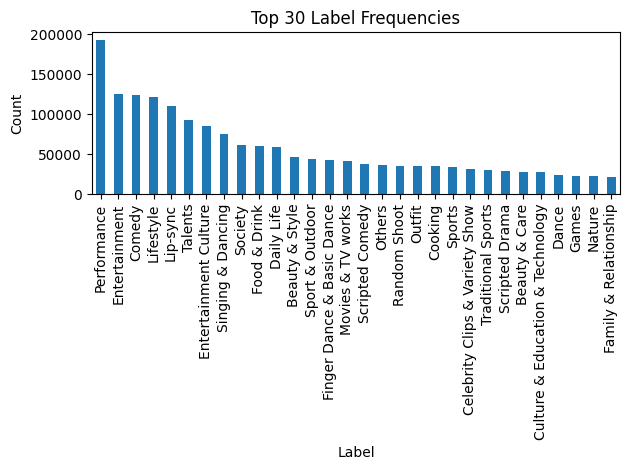

In [11]:
label_counts.head(30).plot(kind="bar")
plt.title("Top 30 Label Frequencies")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()